In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import textwrap
import yaml

from _configs.country_config import *
from _configs.files_config import *
from _configs.run_config import *

from _utils.utils import *

In [2]:
input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_validation.yml").read_text(encoding="utf-8"))

population_scale_from_input_yml = input_data["population_demographic"]["artificial_rescaling_of_population_size"]
starting_date = input_data["simulation_timeframe"]["starting_date"]
ending_date = input_data["simulation_timeframe"]["ending_date"]
birth_rate_from_config = input_data["population_demographic"]["birth_rate"]
public_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][0]
private_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][1]

print(f"Population scale: {population_scale_from_input_yml}")
print(f"Starting date: {starting_date}")
print(f"Ending date: {ending_date}")
print(f"Birth rate: {birth_rate_from_config}")
print(f"Public percentage: {public_pct}")
print(f"Private percentage: {private_pct}")


print(country_code)

exp_path = validation_path
output_path = Path(exp_path) / "output"
analysis_path = Path(exp_path) / "analysis"
os.makedirs(analysis_path, exist_ok=True)

print(data_path)
print(output_path)
print(analysis_path)

Population scale: 0.25
Starting date: 2011/1/1
Ending date: 2024/1/1
Birth rate: 0.0335
Public percentage: 0.445
Private percentage: 0.555
ng-se
DATA
validation_runs/validation_init_pop_21.12M.asc_0.25_population_scale_multiple_pattern_20_replicates/output
validation_runs/validation_init_pop_21.12M.asc_0.25_population_scale_multiple_pattern_20_replicates/analysis


## Population

## <span style="color:red"> DO NOT USE CALIBRATION YEAR HERE, USE INCIDENCE DATA </span>

In [3]:
incidence_calibration_start_date = f'{incidence_comparison_year}-01-01'
incidence_calibration_end_date = f'{incidence_comparison_year + 1}-01-01'   # Calibrate from Jan 1 of the comparison year to end of that year (Jan 1 of the next year)
print(f"Calibration period: {incidence_calibration_start_date} to {incidence_calibration_end_date}")

Calibration period: 2021-01-01 to 2022-01-01


In [4]:
output_1_db = output_path / "validation_monthly_data_13.db"
print(f"Reading monthly data from: {output_1_db}")
# date = get_table_with_columns(output_1_db, ["*"], "monthly_data")
date = get_table(output_1_db, "monthly_data")
# Load yaml input file
date['date'] = pd.to_datetime(starting_date) + pd.to_timedelta(date['days_elapsed'], unit='D')
date = date.rename(columns={"id": "monthly_data_id"})
date = date.sort_values("date")
date_dict = date.set_index("monthly_data_id")["date"].to_dict()

Reading monthly data from: validation_runs/validation_init_pop_21.12M.asc_0.25_population_scale_multiple_pattern_20_replicates/output/validation_monthly_data_13.db


In [5]:
print(f"Date dict info:")
print(f"  Number of entries: {len(date_dict)}")
print(f"  First entry: {list(date_dict.items())[0]}")
print(f"  Last entry: {list(date_dict.items())[-1]}")

Date dict info:
  Number of entries: 157
  First entry: (1, Timestamp('2011-01-01 00:00:00'))
  Last entry: (157, Timestamp('2024-01-01 00:00:00'))


In [6]:
agg_population_data = pd.read_csv(analysis_path / "agg_population_pixel.csv")
agg_population_data["date"] = agg_population_data["monthly_data_id"].map(date_dict)
agg_population_data

,monthly_data_id,location_id,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,...,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,population_20,date
0,1,0,305,305,305,305,305,305,305,305,...,305,305,305,305,305,305,305,305,305,2011-01-01
1,1,1,586,586,586,586,586,586,586,586,...,587,586,586,586,586,586,586,586,586,2011-01-01
2,1,2,323,323,323,323,323,323,323,323,...,323,323,323,323,323,323,323,323,323,2011-01-01
3,1,3,135,135,135,135,135,135,135,135,...,135,135,135,135,135,135,135,135,135,2011-01-01
4,1,4,555,555,555,555,555,555,555,555,...,555,555,555,555,555,555,555,555,555,2011-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075602,157,6846,1193,1156,1232,1234,1214,1212,1175,1174,...,1151,1186,1203,1185,1236,1184,1198,1208,1220,2024-01-01
1075603,157,6847,1954,1906,1981,1945,1847,1977,1927,1909,...,1922,1951,1876,1900,1947,1962,1942,1863,1905,2024-01-01
1075604,157,6848,3299,3341,3292,3296,3329,3366,3363,3321,...,3262,3308,3334,3295,3236,3310,3205,3300,3356,2024-01-01
1075605,157,6849,833,873,813,843,876,830,834,837,...,860,834,848,835,877,827,909,853,849,2024-01-01


In [7]:
# 1. See the actual spread of dates being mapped
# print(sorted(date_dict.items()))

# 2. Confirm dtype and values of the calibration window
print("calibration_start_date:", incidence_calibration_start_date, type(incidence_calibration_start_date))
print("calibration_end_date:", incidence_calibration_end_date, type(incidence_calibration_end_date))

# 3. Confirm dtype of the date column itself
print("Date column dtype:", agg_population_data["date"].dtype)
print("Date column range:", agg_population_data["date"].min(), "-", agg_population_data["date"].max())

# 4. Check how many unique dates exist in the full range
# print(agg_population_data["date"].nunique())
# print(sorted(agg_population_data["date"].unique()))

calibration_start_date: 2021-01-01 <class 'str'>
calibration_end_date: 2022-01-01 <class 'str'>
Date column dtype: datetime64[us]
Date column range: 2011-01-01 00:00:00 - 2024-01-01 00:00:00


In [8]:
mask = (agg_population_data["date"] >= incidence_calibration_start_date) & (agg_population_data["date"] <= incidence_calibration_end_date)
print("Number of True values in mask:", mask.sum())

agg_population_data_at_calibration = agg_population_data.loc[(agg_population_data["date"] >= incidence_calibration_start_date) & (agg_population_data["date"] <= incidence_calibration_end_date), :].reset_index(drop=True)
columns_to_drop = ["monthly_data_id","location_id", "date"]
agg_population_data_at_calibration["mean"] = agg_population_data_at_calibration.drop(columns=columns_to_drop).mean(axis=1)
agg_population_data_at_calibration

Number of True values in mask: 89063


,monthly_data_id,location_id,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,...,population_13,population_14,population_15,population_16,population_17,population_18,population_19,population_20,date,mean
0,121,0,369,344,362,346,354,339,373,364,...,358,378,349,362,353,358,367,356,2021-01-01,358.95
1,121,1,699,673,672,664,676,695,676,678,...,671,692,673,677,716,717,694,662,2021-01-01,680.30
2,121,2,381,412,373,394,396,398,368,383,...,397,386,383,388,410,396,373,388,2021-01-01,390.10
3,121,3,159,157,154,153,147,150,156,157,...,172,162,146,160,157,161,155,161,2021-01-01,156.65
4,121,4,660,658,648,666,692,668,632,671,...,666,663,663,669,644,663,637,656,2021-01-01,656.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89058,133,6846,1136,1121,1177,1190,1170,1182,1154,1162,...,1152,1178,1141,1189,1149,1169,1200,1185,2022-01-01,1159.40
89059,133,6847,1910,1842,1904,1888,1825,1912,1871,1846,...,1891,1826,1830,1874,1888,1872,1819,1865,2022-01-01,1865.70
89060,133,6848,3211,3219,3193,3210,3262,3226,3248,3221,...,3209,3197,3169,3117,3222,3082,3191,3238,2022-01-01,3193.50
89061,133,6849,805,851,804,839,834,793,820,790,...,803,817,813,863,800,854,830,840,2022-01-01,820.45


In [9]:
pop_cols = [f"population_{i}" for i in range(1, 16)]

agg_population_totals_by_bucket = (
    agg_population_data_at_calibration
    .groupby("date")[pop_cols]   # sum over all location_ids per date
    .sum()
    .mean()                      # mean across dates
    / population_scale_from_input_yml
)

# print("Total population from mean of sims (per population bucket):")
# print(agg_population_totals_by_bucket)

agg_population_totals_by_bucket_df = (
    agg_population_totals_by_bucket
    .rename("total_population")
    .rename_axis("population_bucket")
    .reset_index()
)

agg_population_totals_by_bucket_df["total_population"] = agg_population_totals_by_bucket_df["total_population"].apply(lambda x: f"{x:,.0f}")

agg_population_totals_by_bucket_df

# print(agg_population_totals_by_bucket_df)


,population_bucket,total_population
0,population_1,"25,009,444"
1,population_2,"25,009,568"
2,population_3,"25,022,278"
3,population_4,"25,009,875"
4,population_5,"25,005,049"
5,population_6,"25,012,558"
6,population_7,"25,016,764"
7,population_8,"25,008,114"
8,population_9,"25,011,856"
9,population_10,"24,999,006"


In [10]:
initial_population_raster = read_raster_to_df_like_masim(initial_population_projected_raster_path)
population_raster_calibration_year = read_raster_to_df_like_masim(projected_population_calibration_year_raster_path)
observed_incidence_per_district = pd.read_csv(f"{data_path}/Observed_Incidence_Per_District_{incidence_comparison_year}.csv")
observed_incidence_per_district.drop(observed_incidence_per_district.tail(1).index, inplace = True) # Remove the last row which is a total ro
pop_from_csv = observed_incidence_per_district['Population (2021 target based on worldometers birth rate and wordpop raster counts)'].sum()


initial_population_raster_sum = initial_population_raster[0].loc[:, "value"].sum()
population_raster_sum = population_raster_calibration_year[0].loc[:, "value"].sum()
# population_at_calibration_mean = population_at_calibration.groupby(["date"])["population"].sum().mean()/country.population_scale
agg_population_data_at_calibration_mean = agg_population_data_at_calibration.groupby(["date"])["mean"].sum().mean()/population_scale_from_input_yml

# agg_population_data_at_calibration_mean = agg_population_data_at_calibration.groupby(["date"])["mean"].sum()

print(f"Agg population data at calibration ")
print(agg_population_data_at_calibration)


print(f"Total initial population from raster:", f"{initial_population_raster_sum:,.0f}")
print(f"Total projected population from raster ({calibration_year}):", f"{population_raster_sum:,.0f}")
print(f"Total population from Incidence Data csv ({incidence_comparison_year}):", f"{pop_from_csv:,.0f}")
print(f"Total population from mean of {validation_replicates} sims:", f"{agg_population_data_at_calibration_mean:,.0f}")


Generated 6851 locations from 58156 total cells, 51305 cells with no data
Generated 6851 locations from 58156 total cells, 51305 cells with no data
Agg population data at calibration 
       monthly_data_id  location_id  population_1  population_2  population_3  \
0                  121            0           369           344           362   
1                  121            1           699           673           672   
2                  121            2           381           412           373   
3                  121            3           159           157           154   
4                  121            4           660           658           648   
...                ...          ...           ...           ...           ...   
89058              133         6846          1136          1121          1177   
89059              133         6847          1910          1842          1904   
89060              133         6848          3211          3219          3193   
89061 

## Cases

In [11]:
agg_clinical_episodes_data = pd.read_csv(analysis_path / f"agg_clinical_episodes_pixel.csv")
agg_clinical_episodes_data["date"] = agg_clinical_episodes_data["monthly_data_id"].map(date_dict)
agg_clinical_episodes_data_at_calibration = agg_clinical_episodes_data.loc[(agg_clinical_episodes_data["date"] >= incidence_calibration_start_date) & (agg_clinical_episodes_data["date"] <= incidence_calibration_end_date), :].reset_index(drop=True)
columns_to_drop = ["monthly_data_id","location_id", "date"]
agg_clinical_episodes_data_at_calibration["mean"] = agg_clinical_episodes_data_at_calibration.drop(columns=columns_to_drop).mean(axis=1)

In [12]:
agg_clinical_episodes_data_at_calibration

,monthly_data_id,location_id,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,clinical_episodes_8,...,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19,clinical_episodes_20,date,mean
0,121,0,15,22,14,21,11,10,12,21,...,8,19,9,12,10,14,22,15,2021-01-01,15.55
1,121,1,20,22,40,30,26,25,42,22,...,40,27,35,24,33,30,36,35,2021-01-01,30.05
2,121,2,9,15,28,17,17,19,25,21,...,15,16,15,15,11,17,9,13,2021-01-01,17.05
3,121,3,5,3,8,6,3,9,8,7,...,7,5,2,4,5,8,4,12,2021-01-01,6.20
4,121,4,24,33,27,31,22,32,25,32,...,36,30,17,31,40,32,30,27,2021-01-01,28.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89058,133,6846,39,40,47,51,55,53,39,48,...,52,47,42,45,42,57,69,51,2022-01-01,49.10
89059,133,6847,81,76,60,79,66,71,89,63,...,61,88,91,70,72,82,77,81,2022-01-01,75.75
89060,133,6848,117,125,147,164,152,125,113,144,...,132,131,137,130,155,120,113,142,2022-01-01,134.30
89061,133,6849,32,40,36,26,41,34,29,34,...,53,39,45,36,25,53,34,45,2022-01-01,36.85


In [13]:
cases_from_csv = observed_incidence_per_district['Total Cases 2021 from projected population and observed incidence']

In [14]:
observed_clinical_cases = cases_from_csv.sum()
agg_clinical_episodes_data_at_calibration_sum = agg_clinical_episodes_data_at_calibration.groupby(["date"])["mean"].sum().sum() / population_scale_from_input_yml

print(f"Total clinical episodes from observed data: {observed_clinical_cases:,.0f}")
print(f"Total clinical episodes from mean total sims: {agg_clinical_episodes_data_at_calibration_sum:,.0f}")

Total clinical episodes from observed data: 7,299,585
Total clinical episodes from mean total sims: 14,731,065


## Treatment

In [15]:
agg_treatment_data = pd.read_csv(analysis_path / f"agg_treatment_pixel.csv")
agg_treatment_data["date"] = agg_treatment_data["monthly_data_id"].map(date_dict)
agg_treatment_data_at_calibration = agg_treatment_data.loc[(agg_treatment_data["date"] >= incidence_calibration_start_date) & (agg_treatment_data["date"] <= incidence_calibration_end_date), :].reset_index(drop=True)
columns_to_drop = ["monthly_data_id","location_id", "date"]
agg_treatment_data_at_calibration["mean"] = agg_treatment_data_at_calibration.drop(columns=columns_to_drop).mean(axis=1)
agg_treatment_data_at_calibration

,monthly_data_id,location_id,treatments_1,treatments_2,treatments_3,treatments_4,treatments_5,treatments_6,treatments_7,treatments_8,...,treatments_13,treatments_14,treatments_15,treatments_16,treatments_17,treatments_18,treatments_19,treatments_20,date,mean
0,121,0,5,6,9,6,6,3,4,10,...,4,9,6,5,8,8,11,5,2021-01-01,6.70
1,121,1,5,8,16,13,9,12,14,7,...,19,9,18,8,16,16,11,19,2021-01-01,13.20
2,121,2,2,7,13,7,5,6,5,5,...,9,9,8,8,8,6,4,4,2021-01-01,6.70
3,121,3,2,3,2,5,2,4,4,5,...,4,3,0,2,4,3,0,3,2021-01-01,2.90
4,121,4,8,10,11,13,8,16,12,11,...,16,12,7,15,19,12,11,12,2021-01-01,11.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89058,133,6846,15,14,26,32,28,28,21,17,...,29,23,21,26,15,33,37,22,2022-01-01,25.10
89059,133,6847,34,38,24,40,20,37,50,32,...,34,46,42,32,30,43,45,43,2022-01-01,37.95
89060,133,6848,62,53,65,81,75,69,59,70,...,71,67,75,58,76,68,62,71,2022-01-01,67.55
89061,133,6849,22,20,16,17,21,19,12,16,...,33,18,24,18,13,19,13,30,2022-01-01,18.75


In [16]:
agg_treatment_data_at_calibration_sum = agg_treatment_data_at_calibration.groupby(["date"])["mean"].sum().sum() / population_scale_from_input_yml
agg_treatment_data_at_calibration_sum_public = (agg_treatment_data_at_calibration.groupby(["date"])["mean"].sum().sum() / population_scale_from_input_yml) * public_pct
agg_treatment_data_at_calibration_sum_private = (agg_treatment_data_at_calibration.groupby(["date"])["mean"].sum().sum() / population_scale_from_input_yml) * private_pct

print(f"Total treated clinical episodes from mean {validation_replicates} sims: {agg_treatment_data_at_calibration_sum:,.0f}")
print(f"Total treated clinical episodes from mean {validation_replicates} sims (public): {agg_treatment_data_at_calibration_sum_public:,.0f}")
print(f"Total treated clinical episodes from mean {validation_replicates} sims (private): {agg_treatment_data_at_calibration_sum_private:,.0f}")

Total treated clinical episodes from mean 20 sims: 7,113,560
Total treated clinical episodes from mean 20 sims (public): 3,165,534
Total treated clinical episodes from mean 20 sims (private): 3,948,026


In [17]:
''' Quick subtraction for untreated cases as an alternative to pulling from db '''

agg_untreated_cases_at_calibration_sum = agg_clinical_episodes_data_at_calibration_sum - agg_treatment_data_at_calibration_sum

print(f"Total untreated clinical episodes from mean {validation_replicates} sims: {agg_untreated_cases_at_calibration_sum:,.0f}")

Total untreated clinical episodes from mean 20 sims: 7,617,505


Length of ax[0].patches: 2
Length of ax[1].patches: 6


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:125: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:125: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3015030/4205512524.py:7: SyntaxWarning: invalid escape sequence '\d'
  ax[0].set_title(f"{incidence_comparison_year} Population Projected vs Simulated$^\dagger$", pad=20)
/tmp/ipykernel_3015030/4205512524.py:9: SyntaxWarning: invalid escape sequence '\d'
  ax[1].set_title(f"{incidence_comparison_year} Clinical Episodes Observed vs Simulated$^\dagger$", pad=20)
/tmp/ipykernel_3015030/4205512524.py:125: SyntaxWarning: invalid escape sequence '\d'
  fig.text(0.5, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",
/tmp/ipykernel_3015030/4205512524.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a F

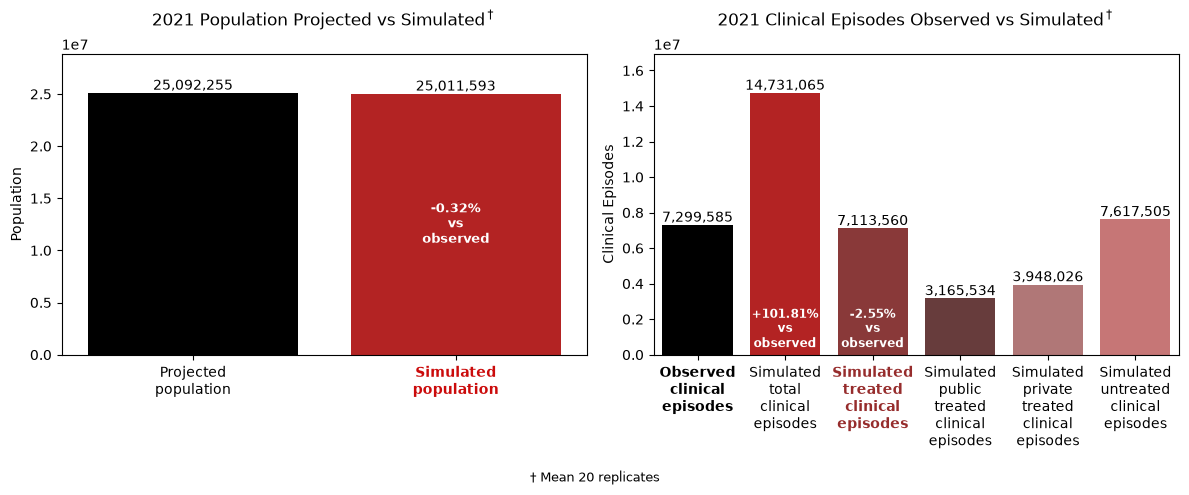

In [18]:
# Plot population and cases at calibration date and compare to raster and csv
# Plot difference between raster and sims, and between csv and sims and show percentage difference on the plot

fig,ax = plt.subplots(1,2, figsize=(12,5))

# Add titles and labels
ax[0].set_title(f"{incidence_comparison_year} Population Projected vs Simulated$^\dagger$", pad=20)
ax[0].set_ylabel("Population")
ax[1].set_title(f"{incidence_comparison_year} Clinical Episodes Observed vs Simulated$^\dagger$", pad=20)
ax[1].set_ylabel("Clinical Episodes")

# cases_palette = {
#     "Observed": "#0000FF",              # distinct color
#     "Simulated (Total)": "#FF6666",          
#     "Simulated (Treated)": "#FF0000",             # same color as total, but different label
#     "Simulated (Public)": "#CC0000",     
#     "Simulated (Private)": "#880000",
#     "Simulated (Untreated)": "#440000",
# }

# cases_palette = {
#     "Observed":               "#1A56DB",  # blue — categorically different from all simulated
#     "Simulated (Total)":      "#4D4D4D",  # neutral grey — it's the aggregate, not a "side"
#     "Simulated (Treated)":    "#E31A1C",  # red — anchor color for the treated branch
#     "Simulated (Public)":     "#FB9A99",  # light red — tint of Treated (its subset)
#     "Simulated (Private)":    "#99000D",  # dark red/maroon — shade of Treated (its subset)
#     "Simulated (Untreated)":  "#FF7F00",  # orange — distinct hue, sibling to Treated
# }

cases_palette = {
    "Observed":               "#000000",  # black, outside the family entirely

    "Simulated (Total)":      "#CB0B0B",  # hsl(0, 90%, 42%) — vivid anchor

    "Simulated (Treated)":    "#962C2C",  # hsl(0, 55%, 38%) — muted, dark half
    "Simulated (Untreated)":  "#D36969",  # hsl(0, 55%, 62%) — muted, light half

    "Simulated (Public)":     "#6E3535",  # hsl(0, 35%, 32%) — dusty, dark subset
    "Simulated (Private)":    "#B96E6E",  # hsl(0, 35%, 58%) — dusty, light subset
}

plot_pop = sns.barplot(
    x=["Projected population", "Simulated population"],
    y=[pop_from_csv, agg_population_data_at_calibration_mean],
    hue=["Observed", "Simulated (Total)"],
    palette=cases_palette,
    legend=False,
    ax=ax[0]
 )
    
plot_cases = sns.barplot(
    x=["Observed clinical episodes", "Simulated total clinical episodes", "Simulated treated clinical episodes", "Simulated public treated clinical episodes", "Simulated private treated clinical episodes", "Simulated untreated clinical episodes"],
    y=[observed_clinical_cases, agg_clinical_episodes_data_at_calibration_sum, agg_treatment_data_at_calibration_sum, agg_treatment_data_at_calibration_sum_public, agg_treatment_data_at_calibration_sum_private, agg_untreated_cases_at_calibration_sum],
    hue=["Observed", "Simulated (Total)", "Simulated (Treated)", "Simulated (Public)", "Simulated (Private)", "Simulated (Untreated)"],
    palette=cases_palette,
    legend=False,
    ax=ax[1]
 )

# Calculate percentage differences
pop_pct_diff = (agg_population_data_at_calibration_mean - pop_from_csv) / pop_from_csv * 100
cases_pct_diff_total = (agg_clinical_episodes_data_at_calibration_sum - observed_clinical_cases) / observed_clinical_cases * 100
cases_pct_diff_treated = (agg_treatment_data_at_calibration_sum - observed_clinical_cases) / observed_clinical_cases * 100

print(f"Length of ax[0].patches: {len(ax[0].patches)}")
print(f"Length of ax[1].patches: {len(ax[1].patches)}")

# Annotate bars with values and percentage differences
for i, (bar, val) in enumerate(zip(ax[0].patches, [pop_from_csv, agg_population_data_at_calibration_mean])):
    ax[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
               f'{val:,.0f}', ha='center', va='bottom', fontsize=10)

# Add percentage difference annotation on the second bar (population)
# bar = ax[0].patches[1]
ax[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 0.5,
           f'{pop_pct_diff:+.2f}%\nvs\nobserved', ha='center', va='center',
           fontsize=9, color='white', fontweight=600)

# Annotate treatment bars with values
treatment_values = [observed_clinical_cases, agg_clinical_episodes_data_at_calibration_sum, agg_treatment_data_at_calibration_sum, agg_treatment_data_at_calibration_sum_public, agg_treatment_data_at_calibration_sum_private, agg_untreated_cases_at_calibration_sum]
for bar, val in zip(ax[1].patches, treatment_values):
    ax[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
               f'{val:,.0f}', ha='center', va='bottom', fontsize=10)

observed_bar_height = ax[1].patches[0].get_height()
# Add percentage difference annotations on treatment bars (relative to csv)
for i, (bar, pct) in enumerate(zip(ax[1].patches[1:], [cases_pct_diff_total, cases_pct_diff_treated])):
    label = f'{pct:+.2f}%\nvs\nobserved'
    ax[1].text(bar.get_x() + bar.get_width() / 2, 200_000,
               label, ha='center', va='bottom',
               fontsize=8.5, color='white', fontweight='demibold')  # Use 'semi-bold' for better visibility on dark background

wrap_width = 12  
ax[0].set_xticklabels([textwrap.fill(label.get_text(), wrap_width) for label in ax[0].get_xticklabels()])
ax[1].set_xticklabels([textwrap.fill(label.get_text(), wrap_width) for label in ax[1].get_xticklabels()])

label_colors_0 = {
    "Observed population": cases_palette["Observed"],
    "Simulated population": cases_palette["Simulated (Total)"],
}

label_colors_1 = {
    "Observed clinical episodes": cases_palette["Observed"],
    "Simulated treated clinical episodes": cases_palette["Simulated (Treated)"],
}

for label in ax[0].get_xticklabels():
    label_text = label.get_text().replace("\n", " ")
    if label_text in label_colors_0:
        label.set_color(label_colors_0[label_text])
        label.set_fontweight('bold')

for label in ax[1].get_xticklabels():
    label_text = label.get_text().replace("\n", " ")
    if label_text in label_colors_1:
        label.set_color(label_colors_1[label_text])
        label.set_fontweight('bold')

ax[0].margins(y=0.15)
ax[1].margins(y=0.15)
ax[0].tick_params(axis='x', labelrotation=0)
ax[1].tick_params(axis='x', labelrotation=0)

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.5, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",
          ha='center', va='bottom', fontsize=9)

plt.savefig(f"{analysis_path}/{incidence_comparison_year}_projected_vs_simulated_population_and_incidence.png", dpi=200)
plt.show()